In [1]:
features_path = DATA_DIR / "supermarket_price_direction_features_h1_t05.parquet"

print(features_path)
print("File exists:", features_path.exists())

df = pd.read_parquet(features_path)

df.shape

NameError: name 'DATA_DIR' is not defined

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

PROJECT_ROOT = Path("..")
DATA_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results" / "baselines"
FIG_DIR = PROJECT_ROOT / "figures" / "baselines"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

features_path = DATA_DIR / "supermarket_price_direction_features_h1_t05.parquet"

print(features_path)
print("File exists:", features_path.exists())

df = pd.read_parquet(features_path)

df.shape

../data/processed/supermarket_price_direction_features_h1_t05.parquet
File exists: True


(8711346, 28)

In [3]:
df["date"].min(), df["date"].max()

(Timestamp('2024-01-09 00:00:00'), Timestamp('2024-04-12 00:00:00'))

In [4]:
df["target_direction_h1_t05"].value_counts(normalize=True)

target_direction_h1_t05
Stable    0.984456
Up        0.007806
Down      0.007738
Name: proportion, dtype: float64

In [5]:
target_col = "target_direction_h1_t05"

train_end = pd.Timestamp("2024-03-10")
val_end = pd.Timestamp("2024-03-24")

train_df = df[df["date"] <= train_end].copy()

val_df = df[
    (df["date"] > train_end) &
    (df["date"] <= val_end)
].copy()

test_df = df[df["date"] > val_end].copy()

split_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "start_date": [
        train_df["date"].min(),
        val_df["date"].min(),
        test_df["date"].min(),
    ],
    "end_date": [
        train_df["date"].max(),
        val_df["date"].max(),
        test_df["date"].max(),
    ],
    "rows": [
        len(train_df),
        len(val_df),
        len(test_df),
    ],
})

split_summary["row_share"] = split_summary["rows"] / len(df)

split_summary

,split,start_date,end_date,rows,row_share
0,train,2024-01-09,2024-03-10,5765174,0.661801
1,validation,2024-03-11,2024-03-24,1030166,0.118256
2,test,2024-03-25,2024-04-12,1916006,0.219944


In [6]:
split_summary.to_csv(
    RESULTS_DIR / "time_based_split_summary.csv",
    index=False
)

In [7]:
def class_distribution_by_split(data, split_name):
    out = (
        data[target_col]
        .value_counts(normalize=True)
        .rename_axis("target_direction")
        .reset_index(name="share")
    )
    out["split"] = split_name
    out["count"] = (
        data[target_col]
        .value_counts()
        .reindex(out["target_direction"])
        .values
    )
    return out

split_class_distribution = pd.concat(
    [
        class_distribution_by_split(train_df, "train"),
        class_distribution_by_split(val_df, "validation"),
        class_distribution_by_split(test_df, "test"),
    ],
    ignore_index=True
)

split_class_distribution

,target_direction,share,split,count
0,Stable,0.984779,train,5677422
1,Up,0.007745,train,44652
2,Down,0.007476,train,43100
3,Stable,0.981859,validation,1011478
4,Down,0.009375,validation,9658
5,Up,0.008766,validation,9030
6,Stable,0.984879,test,1887035
7,Down,0.007645,test,14648
8,Up,0.007475,test,14323


In [8]:
split_class_distribution.to_csv(
    RESULTS_DIR / "split_class_distribution.csv",
    index=False
)

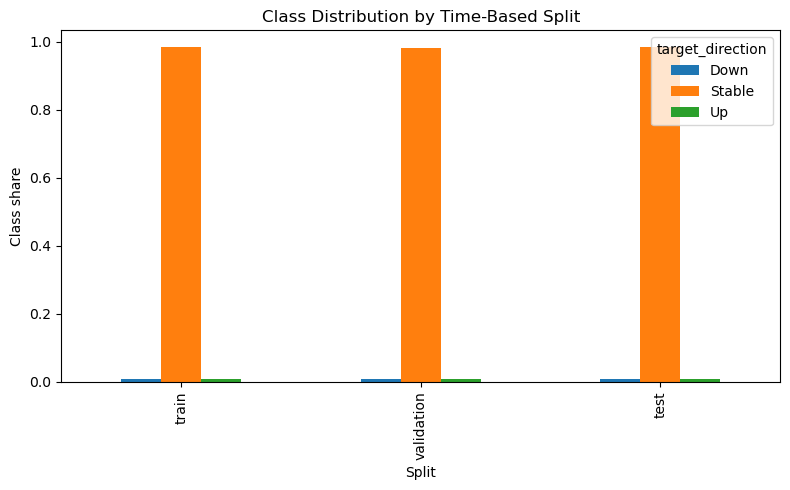

In [9]:
plot_split_class = (
    split_class_distribution
    .pivot(index="split", columns="target_direction", values="share")
    .loc[["train", "validation", "test"]]
)

plot_split_class.plot(kind="bar", figsize=(8, 5))
plt.xlabel("Split")
plt.ylabel("Class share")
plt.title("Class Distribution by Time-Based Split")
plt.tight_layout()
plt.savefig(FIG_DIR / "class_distribution_by_split.png", dpi=300)
plt.show()

In [10]:
majority_class = train_df[target_col].mode()[0]
majority_class

'Stable'

In [11]:
def evaluate_predictions(y_true, y_pred, model_name, split_name):
    metrics = {
        "model": model_name,
        "split": split_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
    }
    return metrics

baseline_results = []

for split_name, split_data in [
    ("train", train_df),
    ("validation", val_df),
    ("test", test_df),
]:
    y_true = split_data[target_col]
    y_pred = np.repeat(majority_class, len(split_data))

    baseline_results.append(
        evaluate_predictions(
            y_true,
            y_pred,
            model_name="majority_class_stable",
            split_name=split_name
        )
    )

baseline_results_df = pd.DataFrame(baseline_results)

baseline_results_df

,model,split,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,majority_class_stable,train,0.984779,0.333333,0.330777,0.977227
1,majority_class_stable,validation,0.981859,0.333333,0.330282,0.972872
2,majority_class_stable,test,0.984879,0.333333,0.330794,0.977377


In [12]:
baseline_results_df.to_csv(
    RESULTS_DIR / "majority_class_baseline_metrics.csv",
    index=False
)

In [13]:
for split_name, split_data in [
    ("validation", val_df),
    ("test", test_df),
]:
    y_true = split_data[target_col]
    y_pred = np.repeat(majority_class, len(split_data))

    report = classification_report(
        y_true,
        y_pred,
        labels=["Down", "Stable", "Up"],
        output_dict=True,
        zero_division=0
    )

    report_df = pd.DataFrame(report).T
    report_df.to_csv(
        RESULTS_DIR / f"majority_class_classification_report_{split_name}.csv"
    )

    display(report_df)

,precision,recall,f1-score,support
Down,0.000000,0.000000,0.000000,9.658000e+03
Stable,0.981859,1.000000,0.990847,1.011478e+06
Up,0.000000,0.000000,0.000000,9.030000e+03
accuracy,0.981859,0.981859,0.981859,9.818592e-01
macro avg,0.327286,0.333333,0.330282,1.030166e+06
weighted avg,0.964048,0.981859,0.972872,1.030166e+06


,precision,recall,f1-score,support
Down,0.000000,0.000000,0.000000,1.464800e+04
Stable,0.984879,1.000000,0.992382,1.887035e+06
Up,0.000000,0.000000,0.000000,1.432300e+04
accuracy,0.984879,0.984879,0.984879,9.848795e-01
macro avg,0.328293,0.333333,0.330794,1.916006e+06
weighted avg,0.969988,0.984879,0.977377,1.916006e+06


In [14]:
y_true_test = test_df[target_col]
y_pred_test = np.repeat(majority_class, len(test_df))

cm = confusion_matrix(
    y_true_test,
    y_pred_test,
    labels=["Down", "Stable", "Up"]
)

cm_df = pd.DataFrame(
    cm,
    index=["Actual_Down", "Actual_Stable", "Actual_Up"],
    columns=["Pred_Down", "Pred_Stable", "Pred_Up"]
)

cm_df

,Pred_Down,Pred_Stable,Pred_Up
Actual_Down,0,14648,0
Actual_Stable,0,1887035,0
Actual_Up,0,14323,0


In [15]:
cm_df.to_csv(
    RESULTS_DIR / "majority_class_confusion_matrix_test.csv"
)

In [16]:
split_summary
split_class_distribution
baseline_results_df
cm_df

,Pred_Down,Pred_Stable,Pred_Up
Actual_Down,0,14648,0
Actual_Stable,0,1887035,0
Actual_Up,0,14323,0


In [17]:
def recent_change_reversal_baseline(data):
    preds = np.where(
        data["price_change_pct_lag_1"] > 0,
        "Down",
        np.where(
            data["price_change_pct_lag_1"] < 0,
            "Up",
            "Stable"
        )
    )
    return preds

In [18]:
heuristic_results = []

for split_name, split_data in [
    ("train", train_df),
    ("validation", val_df),
    ("test", test_df),
]:
    y_true = split_data[target_col]
    y_pred = recent_change_reversal_baseline(split_data)

    heuristic_results.append(
        evaluate_predictions(
            y_true,
            y_pred,
            model_name="recent_change_reversal",
            split_name=split_name
        )
    )

heuristic_results_df = pd.DataFrame(heuristic_results)

heuristic_results_df

,model,split,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,recent_change_reversal,train,0.973800,0.391338,0.393866,0.973207
1,recent_change_reversal,validation,0.969740,0.374875,0.379245,0.968188
2,recent_change_reversal,test,0.972545,0.394376,0.393887,0.972672


In [19]:
heuristic_results_df.to_csv(
    RESULTS_DIR / "recent_change_reversal_baseline_metrics.csv",
    index=False
)

In [20]:
all_baseline_results = pd.concat(
    [
        baseline_results_df,
        heuristic_results_df
    ],
    ignore_index=True
)

all_baseline_results

,model,split,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,majority_class_stable,train,0.984779,0.333333,0.330777,0.977227
1,majority_class_stable,validation,0.981859,0.333333,0.330282,0.972872
2,majority_class_stable,test,0.984879,0.333333,0.330794,0.977377
3,recent_change_reversal,train,0.973800,0.391338,0.393866,0.973207
4,recent_change_reversal,validation,0.969740,0.374875,0.379245,0.968188
5,recent_change_reversal,test,0.972545,0.394376,0.393887,0.972672


In [21]:
all_baseline_results.to_csv(
    RESULTS_DIR / "baseline_metrics_comparison.csv",
    index=False
)

In [22]:
for split_name, split_data in [
    ("validation", val_df),
    ("test", test_df),
]:
    y_true = split_data[target_col]
    y_pred = recent_change_reversal_baseline(split_data)

    report = classification_report(
        y_true,
        y_pred,
        labels=["Down", "Stable", "Up"],
        output_dict=True,
        zero_division=0
    )

    report_df = pd.DataFrame(report).T
    report_df.to_csv(
        RESULTS_DIR / f"recent_change_reversal_classification_report_{split_name}.csv"
    )

    display(report_df)

,precision,recall,f1-score,support
Down,0.099565,0.075792,0.086067,9.658000e+03
Stable,0.982942,0.986375,0.984656,1.011478e+06
Up,0.072280,0.062458,0.067011,9.030000e+03
accuracy,0.969740,0.969740,0.969740,9.697398e-01
macro avg,0.384929,0.374875,0.379245,1.030166e+06
weighted avg,0.966678,0.969740,0.968188,1.030166e+06


,precision,recall,f1-score,support
Down,0.106124,0.104588,0.105350,1.464800e+04
Stable,0.986244,0.985962,0.986103,1.887035e+06
Up,0.087954,0.092578,0.090207,1.432300e+04
accuracy,0.972545,0.972545,0.972545,9.725450e-01
macro avg,0.393441,0.394376,0.393887,1.916006e+06
weighted avg,0.972801,0.972545,0.972672,1.916006e+06


In [23]:
y_true_test = test_df[target_col]
y_pred_test = recent_change_reversal_baseline(test_df)

heuristic_cm = confusion_matrix(
    y_true_test,
    y_pred_test,
    labels=["Down", "Stable", "Up"]
)

heuristic_cm_df = pd.DataFrame(
    heuristic_cm,
    index=["Actual_Down", "Actual_Stable", "Actual_Up"],
    columns=["Pred_Down", "Pred_Stable", "Pred_Up"]
)

heuristic_cm_df

,Pred_Down,Pred_Stable,Pred_Up
Actual_Down,1532,13082,34
Actual_Stable,12775,1860544,13716
Actual_Up,129,12868,1326


In [24]:
heuristic_cm_df.to_csv(
    RESULTS_DIR / "recent_change_reversal_confusion_matrix_test.csv"
)

In [25]:
print("Baseline result files:")
for p in sorted(RESULTS_DIR.glob("*.csv")):
    print(p.name)

print("\nBaseline figures:")
for p in sorted(FIG_DIR.glob("*.png")):
    print(p.name)

Baseline result files:
baseline_metrics_comparison.csv
majority_class_baseline_metrics.csv
majority_class_classification_report_test.csv
majority_class_classification_report_validation.csv
majority_class_confusion_matrix_test.csv
recent_change_reversal_baseline_metrics.csv
recent_change_reversal_classification_report_test.csv
recent_change_reversal_classification_report_validation.csv
recent_change_reversal_confusion_matrix_test.csv
split_class_distribution.csv
time_based_split_summary.csv

Baseline figures:
class_distribution_by_split.png


In [26]:
all_baseline_results
heuristic_cm_df

,Pred_Down,Pred_Stable,Pred_Up
Actual_Down,1532,13082,34
Actual_Stable,12775,1860544,13716
Actual_Up,129,12868,1326
